# Introduction to Distributions

*If you haven't read the [Getting Started tutorial](../tutorials/getting_started.ipynb), read it first. This notebook is a more detailed look at distributions, one of ProbPipe's three core types.*

ProbPipe represents probability distributions as Python objects. Each distribution lets you do a subset of the usual things — draw samples, evaluate the density, compute moments, take expectations — through a uniform set of **operations** (**ops**) defined at the package level:

| Op | Meaning |
|---|---|
| `sample(dist, key=..., sample_shape=...)` | Draw samples |
| `log_prob(dist, x)` | Log density (or log mass) at `x` |
| `prob(dist, x)` | Density at `x` — i.e. `exp(log_prob)` |
| `mean(dist)` | `E[X]` |
| `variance(dist)` | `Var[X]` per element |
| `cov(dist)` | Covariance matrix |
| `expectation(dist, f, ...)` | `E[f(X)]` — exact when possible, MC otherwise |

Not every distribution supports every op. An empirical approximation — say, samples from MCMC — can be sampled but has no closed-form density; a Gaussian random function has a density but no finite-dimensional sample. ProbPipe makes these distinctions explicit through **protocols**: lightweight interfaces that say which ops a given distribution supports. Use `isinstance(dist, SupportsX)` to check.

| Protocol | Op | Meaning |
|---|---|---|
| `SupportsSampling` | `sample` | Can draw samples |
| `SupportsLogProb` | `log_prob` / `prob` | Has a density or mass function |
| `SupportsMean` | `mean` | Can compute its mean |
| `SupportsVariance` | `variance` | Can compute its variance |
| `SupportsCovariance` | `cov` | Can compute its covariance matrix |
| `SupportsConditioning` | `condition_on` | Has a fast built-in `condition_on` path (e.g., closed-form or amortized) |
| `SupportsExpectation` | `expectation` | Supports `E[f(X)]` (exact or approximate) |

Each op checks the relevant protocol before dispatching, so calling `log_prob` on something that doesn't support it raises a clear `TypeError` instead of silently returning garbage.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (Normal, Beta, Gamma, Exponential, Bernoulli, Poisson,
                      MultivariateNormal, Dirichlet, Categorical,
                      RecordEmpiricalDistribution,
                      sample, log_prob, prob, mean, variance, cov, expectation)
from probpipe.core.protocols import (SupportsSampling, SupportsLogProb, SupportsMean,
                                     SupportsVariance, SupportsCovariance,
                                     SupportsExpectation)

# TFP sampling occasionally requests float64 internally; JAX's default
# x64-disabled mode silently downgrades to float32 and emits a UserWarning.
# Silence the noise — the downgrade is harmless for this tutorial.
warnings.filterwarnings("ignore", message=r".*Explicitly requested dtype float64.*",
                        category=UserWarning)

## 1. Parametric families

ProbPipe ships the usual parametric distributions, each with the familiar constructor arguments. Every construction requires `name=` — the name propagates through ops and is useful for provenance / diagnostics.

Each distribution also exposes a `.support` property that describes the domain of its density or mass function. ProbPipe's converter registry uses this to guard cross-family conversions; you can also inspect it yourself to sanity-check a model.

In [2]:
n = Normal(loc=2.0, scale=0.5, name="n")
b = Beta(alpha=2.0, beta=5.0, name="b")
g = Gamma(concentration=3.0, rate=1.0, name="g")

for dist in [n, b, g, Poisson(rate=3.0, name="p"), Bernoulli(probs=0.5, name="coin")]:
    print(f"  {type(dist).__name__:10s} event_shape={dist.event_shape}, support={dist.support}")

  Normal     event_shape=(), support=real
  Beta       event_shape=(), support=unit_interval
  Gamma      event_shape=(), support=positive
  Poisson    event_shape=(), support=non_negative_integer
  Bernoulli  event_shape=(), support=boolean


## 2. Sampling

`sample(dist, sample_shape=..., key=...)` draws from the distribution. The output shape is `sample_shape + event_shape` — a `Distribution` always represents one random variable. (If you need an array of distributions, see `DistributionArray` in the [records notebook](02_records.ipynb).)

The `key` argument is optional. When you omit it, ProbPipe derives one from a deterministic per-session counter, so your output stays reproducible within a single interpreter run.

> **Note.** Samples come back wrapped as `NumericRecord` or `NumericRecordArray` (the same containers used everywhere else in ProbPipe), so call `jnp.asarray(...)` when you want a plain array for plotting or slicing.

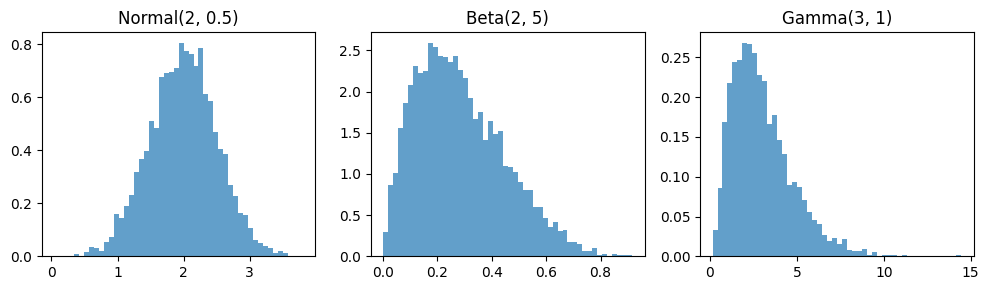

In [3]:
samples_n = jnp.asarray(sample(n, sample_shape=(5000,)))
samples_b = jnp.asarray(sample(b, sample_shape=(5000,)))
samples_g = jnp.asarray(sample(g, sample_shape=(5000,)))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, s, title in zip(axes, [samples_n, samples_b, samples_g],
                        ["Normal(2, 0.5)", "Beta(2, 5)", "Gamma(3, 1)"]):
    ax.hist(np.asarray(s), bins=50, density=True, alpha=0.7)
    ax.set_title(title)
plt.tight_layout(); plt.show()

Discrete distributions work the same way — a `Poisson` returns integer
counts, a `Categorical` returns class indices.

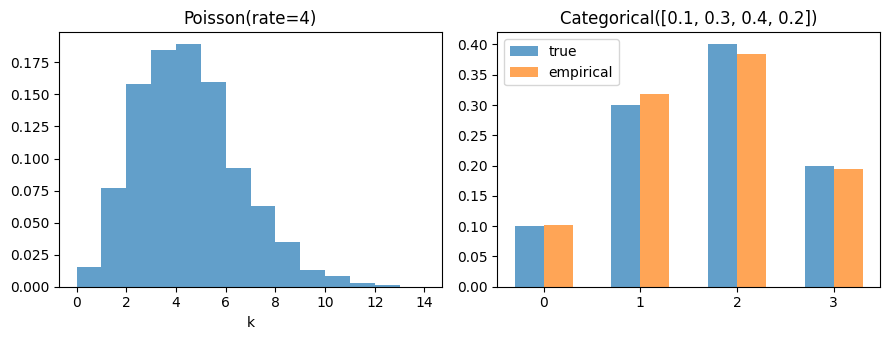

In [4]:
p = Poisson(rate=4.0, name="p")
cat = Categorical(probs=jnp.array([0.1, 0.3, 0.4, 0.2]), name="cat")
samples_p = jnp.asarray(sample(p, sample_shape=(1000,)))
samples_c = jnp.asarray(sample(cat, sample_shape=(1000,)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.hist(np.asarray(samples_p), bins=range(15), density=True, alpha=0.7)
ax1.set_title("Poisson(rate=4)"); ax1.set_xlabel("k")

classes = jnp.arange(4)
empirical = jnp.array([(samples_c == k).sum() for k in classes]) / 1000.0
ax2.bar(classes - 0.15, cat.probs, width=0.3, label="true", alpha=0.7)
ax2.bar(classes + 0.15, empirical, width=0.3, label="empirical", alpha=0.7)
ax2.set_xticks(classes); ax2.set_title("Categorical([0.1, 0.3, 0.4, 0.2])")
ax2.legend()
plt.tight_layout(); plt.show()

## 3. Density and probability

`log_prob(dist, x)` returns the log-density (for continuous distributions) or log-mass (for discrete ones). `prob` is the non-log convenience wrapper. Pass an array of `x` values and you get an array of values back — both ops broadcast.

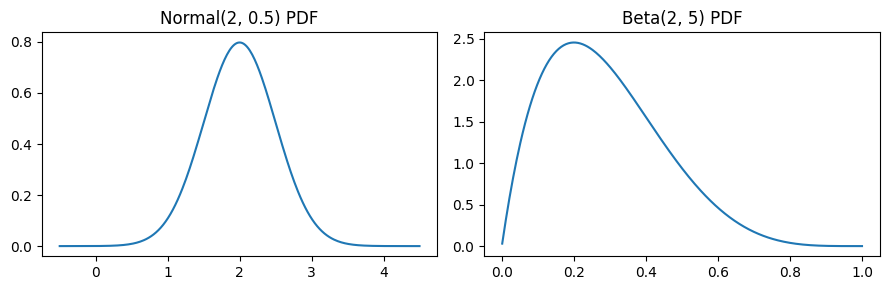

In [5]:
x = jnp.linspace(-0.5, 4.5, 300)
xb = jnp.linspace(0.001, 0.999, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(x, np.asarray(prob(n, x))); ax1.set_title("Normal(2, 0.5) PDF")
ax2.plot(xb, np.asarray(prob(b, xb))); ax2.set_title("Beta(2, 5) PDF")
plt.tight_layout(); plt.show()

## 4. Multivariate distributions

ProbPipe supports common multivariate distributions like `MultivariateNormal` and `Dirichlet`. In the case of `MultivariateNormal`,
for the defining the covariance, the constructor accepts a covariance matrix (`cov=`) or lower-triangular Cholesky factor
(`scale_tril=`). 

MultivariateNormal(name='mvn', event_shape=(2,))
  event_shape=(2,)


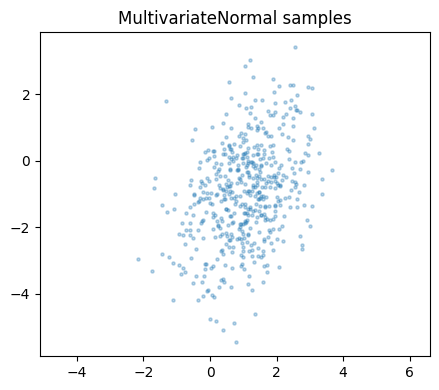

In [6]:
mvn = MultivariateNormal(
    loc=jnp.array([1.0, -1.0]),
    cov=jnp.array([[1.0, 0.5], [0.5, 2.0]]),
    name="mvn",
)
print(mvn)
print(f"  event_shape={mvn.event_shape}")

samples_mvn = np.asarray(sample(mvn, sample_shape=(500,)))
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(np.asarray(samples_mvn[:, 0]), np.asarray(samples_mvn[:, 1]),
           alpha=0.3, s=5)
ax.set_title("MultivariateNormal samples"); ax.axis("equal")
plt.tight_layout(); plt.show()

`Dirichlet` lives on the probability simplex (each draw is a non-negative vector summing to 1) and is the natural prior for `Categorical` probabilities. The plot below puts the first two simplex coordinates on the axes and colours by the third.

Dirichlet(name='d', event_shape=(3,))
  event_shape=(3,)


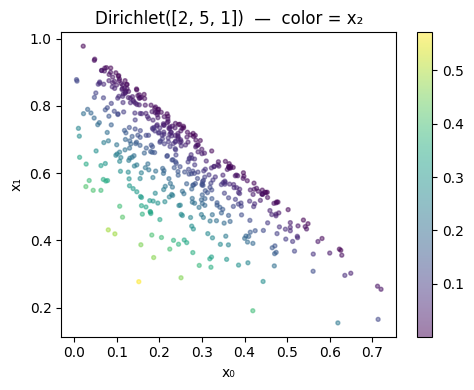

In [7]:
d = Dirichlet(concentration=jnp.array([2.0, 5.0, 1.0]), name="d")
print(d)
print(f"  event_shape={d.event_shape}")
samples_d = jnp.asarray(sample(d, sample_shape=(500,)))

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(np.asarray(samples_d[:, 0]), np.asarray(samples_d[:, 1]),
                c=np.asarray(samples_d[:, 2]), alpha=0.5, s=8, cmap="viridis")
ax.set_xlabel("x₀"); ax.set_ylabel("x₁")
ax.set_title("Dirichlet([2, 5, 1])  —  color = x₂")
plt.colorbar(sc); plt.tight_layout(); plt.show()

## 5. Mean, variance, and covariance

`mean(dist)`, `variance(dist)`, and `cov(dist)` are the three moment ops. For univariate distributions, `mean` and `variance` are scalars and `cov` doesn't apply. For multivariate ones, `mean` is a vector, `variance` returns per-element variances (the diagonal of the full covariance), and `cov` returns the full covariance matrix.

In [8]:
# Scalar distributions: just mean and variance.
for dist in [n, b, g]:
    print(f"  {type(dist).__name__:8s} mean={float(mean(dist)):.4f}, "
          f"variance={float(variance(dist)):.4f}")

# Multivariate: mean is a vector, variance is per-element, cov is the matrix.
print(f"\nMultivariateNormal:")
print(f"  mean:     {jnp.asarray(mean(mvn))}")
print(f"  variance: {jnp.asarray(variance(mvn))}  (the diagonal of cov)")
print(f"  cov:\n{jnp.asarray(cov(mvn))}")

print(f"\nDirichlet:")
print(f"  mean:     {jnp.asarray(mean(d))}")
print(f"  variance: {jnp.asarray(variance(d))}")

  Normal   mean=2.0000, variance=0.2500
  Beta     mean=0.2857, variance=0.0255
  Gamma    mean=3.0000, variance=3.0000

MultivariateNormal:
  mean:     [ 1. -1.]


  variance: [1.        1.9999999]  (the diagonal of cov)
  cov:
[[1.        0.5      ]
 [0.5       1.9999999]]

Dirichlet:
  mean:     [0.25  0.625 0.125]
  variance: [0.02083333 0.02604167 0.01215278]


## 6. General expectations with `expectation`

For the expectation `E[f(X)]` of an arbitrary function `f`, use `expectation(dist, f, ...)`. The result is exact when the distribution's support is finite; otherwise it defaults to a Monte Carlo estimate, returned by default as a `BootstrapDistribution` so you can see the MC sampling error alongside the point estimate.

In [9]:
# MC estimate. The returned BootstrapDistribution carries the sampling error.
ex_sin = expectation(n, lambda x: jnp.sin(x))
print(f"E[sin(N(2, 0.5))] (MC, {ex_sin.n} draws):")
print(f"  point estimate:  {float(mean(ex_sin)):.4f}")
print(f"  MC std error:    {float(jnp.sqrt(variance(ex_sin))):.4f}")
print(f"  returned type:   {type(ex_sin).__name__}")

E[sin(N(2, 0.5))] (MC, 1024 draws):
  point estimate:  0.7992


  MC std error:    0.0071
  returned type:   BootstrapDistribution


If you don't want the MC sampling error tracked through, pass `return_dist=False` and `expectation` returns the point estimate directly:

In [10]:
# Turn off the error-bar wrapping with return_dist=False
ex_plain = expectation(n, lambda x: jnp.sin(x), return_dist=False)
print(f"E[sin(N(2, 0.5))] (return_dist=False):")
print(f"  point estimate:  {float(ex_plain):.4f}")
print(f"  returned type:   {type(ex_plain).__name__}  (no MC error tracked)")

E[sin(N(2, 0.5))] (return_dist=False):
  point estimate:  0.8039
  returned type:   NumericRecord  (no MC error tracked)


For finite-support distributions, `expectation` enumerates over the support and returns an exact value as a `NumericRecord`, rather than a `BootstrapDistribution`:

In [11]:
# Exact expectation on a finite-support distribution — no MC needed
ex_cat = expectation(cat, lambda x: x ** 2)
print(f"\nE[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = {float(ex_cat):.3f}")
print(f"  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = {0*.1 + 1*.3 + 4*.4 + 9*.2:.3f}")
print(f"  returned type: {type(ex_cat).__name__}")


E[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = 3.700
  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = 3.700
  returned type: NumericRecord


## 7. `RecordEmpiricalDistribution` — wrapping samples as a distribution

When you already have a batch of draws — MCMC output, imported data, simulated replicates — `RecordEmpiricalDistribution` wraps them as a first-class distribution. It supports sampling (by resampling the stored points), moments, and covariance, but not `log_prob`: an empirical sample has no density. To get a density estimate from samples, see the [converting-representations notebook](06_converting_representations.ipynb).

In [12]:
raw = (jax.random.normal(jax.random.PRNGKey(8), (200, 2)) * jnp.array([1.0, 3.0])
       + jnp.array([2.0, -1.0]))
emp = RecordEmpiricalDistribution(raw, name="my_samples")
print(emp)
print(f"  n={emp.n}, event_shape={emp.event_shape}")
print(f"  mean={mean(emp)}")
print(f"  variance={variance(emp)}")
print(f"  cov:\n{cov(emp)}")

# Resample from the stored points
resampled = jnp.asarray(sample(emp, sample_shape=(500,)))
print(f"\nresampled shape: {resampled.shape}")

RecordEmpiricalDistribution(n=200, fields=(my_samples))
  n=200, event_shape=(2,)


  mean=NumericRecord(my_samples=array(shape=(2,)))


  variance=NumericRecord(my_samples=array(shape=(2,)))
  cov:
NumericRecord(my_samples=array(shape=(2, 2)))



resampled shape: (500, 2)


## 8. Protocols — what does a distribution actually support?

Use `isinstance(dist, SupportsX)` to check whether a given op is available. The check is duck-typed: any distribution that knows how to do the op satisfies the corresponding protocol, regardless of its inheritance.

In [13]:
# A parametric Normal satisfies everything
print("Normal(2, 0.5):")
for protocol in (SupportsSampling, SupportsLogProb, SupportsMean,
                 SupportsVariance, SupportsExpectation):
    print(f"  {protocol.__name__:25s}: {isinstance(n, protocol)}")

Normal(2, 0.5):
  SupportsSampling         : True
  SupportsLogProb          : True
  SupportsMean             : True
  SupportsVariance         : True
  SupportsExpectation      : True


`RecordEmpiricalDistribution` covers sampling and the moments you can compute from its stored draws, but not `log_prob` — there is no density on an empirical sample:

In [14]:
# RecordEmpiricalDistribution supports sampling + moments, not log_prob
print("\nRecordEmpiricalDistribution:")
for protocol in (SupportsSampling, SupportsLogProb, SupportsMean,
                 SupportsVariance, SupportsCovariance):
    print(f"  {protocol.__name__:25s}: {isinstance(emp, protocol)}")


RecordEmpiricalDistribution:
  SupportsSampling         : True
  SupportsLogProb          : False
  SupportsMean             : True
  SupportsVariance         : True
  SupportsCovariance       : True


Calling an unavailable op produces a clear error, not silent garbage:

In [15]:
try:
    log_prob(emp, jnp.array([0.0, 0.0]))
except TypeError as e:
    print(f"TypeError: {e}")

When you need to call an op the source distribution doesn't support, the **converter registry** can bridge the gap — e.g., wrap a `RecordEmpiricalDistribution` in a KDE for a density estimate, or fit a `Normal` by moment matching. See the [converting-representations notebook](06_converting_representations.ipynb) for the full story.

## 9. Summary

- Every distribution shares the same op set: `sample`, `log_prob`, `prob`, `mean`, `variance`, `cov`, `expectation`.
- Not every distribution supports every op. Use the `SupportsX` protocols to check; calling an unsupported op raises a clear `TypeError`.
- Parametric families (`Normal`, `Beta`, `Gamma`, `MultivariateNormal`, `Dirichlet`, ...) take the usual parameters; all constructors require a `name=`, and each exposes a `.support` constraint used by the converter registry.
- `mean(dist)`, `variance(dist)`, and `cov(dist)` are the moment ops; `expectation(dist, f, ...)` handles general `E[f(X)]` (exact for finite support, MC otherwise).
- `RecordEmpiricalDistribution` wraps a batch of samples as a distribution, so you can use saved draws through the same API as a parametric distribution.

Next up: every distribution returns its samples as a `Record` or `NumericRecord` — covered in the [Records and Record Distributions notebook](02_records.ipynb).